In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

sys.path.append('../../scripts')
import config
from data_pipeline import load_and_prepare_data, load_single_channel
import plots, xgb_scripts, evaluate

In [9]:
all_channels = config.CHANNELS

all_channels_data = {}
for channel in all_channels:
      all_channels_data[channel] = load_single_channel(
                  "../../data/04-03-24", 
                  channel=channel
            )


In [10]:
# Check data integrity: ensure every EIS cycle has corresponding capacity data
end_of_cycle_capacities = {}

for channel, df in all_channels_data.items():
    # Get cycles with EIS data (Ns==6)
    eis_cycles = set(df[df['Ns'] == 6]['cycle number'].unique())
    
    # Get cycles with capacity data (Ns==8)
    capacity_cycles = set(df[df['Ns'] == 8]['cycle number'].unique())
    
    # Check for missing capacity data
    missing_capacity = eis_cycles - capacity_cycles
    missing_eis = capacity_cycles - eis_cycles
    
    print(f"\nChannel {channel} - Data Integrity Check:")
    print(f"  EIS cycles (Ns=6): {len(eis_cycles)}")
    print(f"  Capacity cycles (Ns=8): {len(capacity_cycles)}")
    
    if missing_capacity:
        print(f"  WARNING: EIS cycles missing capacity data: {sorted(missing_capacity)}")
    else:
        print(f"  ✓ All EIS cycles have capacity data")
        
    if missing_eis:
        print(f"  INFO: Capacity cycles missing EIS data: {sorted(missing_eis)}")
    
    # Extract end-of-cycle capacity (only from cycles with both EIS and capacity data)
    valid_cycles = eis_cycles.intersection(capacity_cycles)
    capacity_df = df[df['Ns'] == 8]
    cycle_end_capacities = capacity_df[capacity_df['cycle number'].isin(valid_cycles)].groupby('cycle number')['Capacity/mA.h'].last()
    end_of_cycle_capacities[channel] = cycle_end_capacities
    
    print(f"  Valid cycles (both EIS + capacity): {len(valid_cycles)}")
    print(f"  Capacity range: {cycle_end_capacities.min():.1f} - {cycle_end_capacities.max():.1f} mAh")
    print(f"  Capacity mean: {cycle_end_capacities.mean():.1f} mAh")
    print(f"  Capacity std: {cycle_end_capacities.std():.1f} mAh")



Channel A1 - Data Integrity Check:
  EIS cycles (Ns=6): 267
  Capacity cycles (Ns=8): 267
  ✓ All EIS cycles have capacity data
  Valid cycles (both EIS + capacity): 267
  Capacity range: 2170.0 - 4040.0 mAh
  Capacity mean: 3304.6 mAh
  Capacity std: 433.9 mAh

Channel A2 - Data Integrity Check:
  EIS cycles (Ns=6): 266
  Capacity cycles (Ns=8): 266
  ✓ All EIS cycles have capacity data
  Valid cycles (both EIS + capacity): 266
  Capacity range: 1690.0 - 4030.0 mAh
  Capacity mean: 3230.8 mAh
  Capacity std: 527.0 mAh

Channel A3 - Data Integrity Check:
  EIS cycles (Ns=6): 266
  Capacity cycles (Ns=8): 266
  ✓ All EIS cycles have capacity data
  Valid cycles (both EIS + capacity): 266
  Capacity range: 2370.0 - 3810.0 mAh
  Capacity mean: 3312.9 mAh
  Capacity std: 332.1 mAh

Channel A4 - Data Integrity Check:
  EIS cycles (Ns=6): 269
  Capacity cycles (Ns=8): 269
  ✓ All EIS cycles have capacity data
  Valid cycles (both EIS + capacity): 269
  Capacity range: 198.0 - 4010.0 mAh
  C

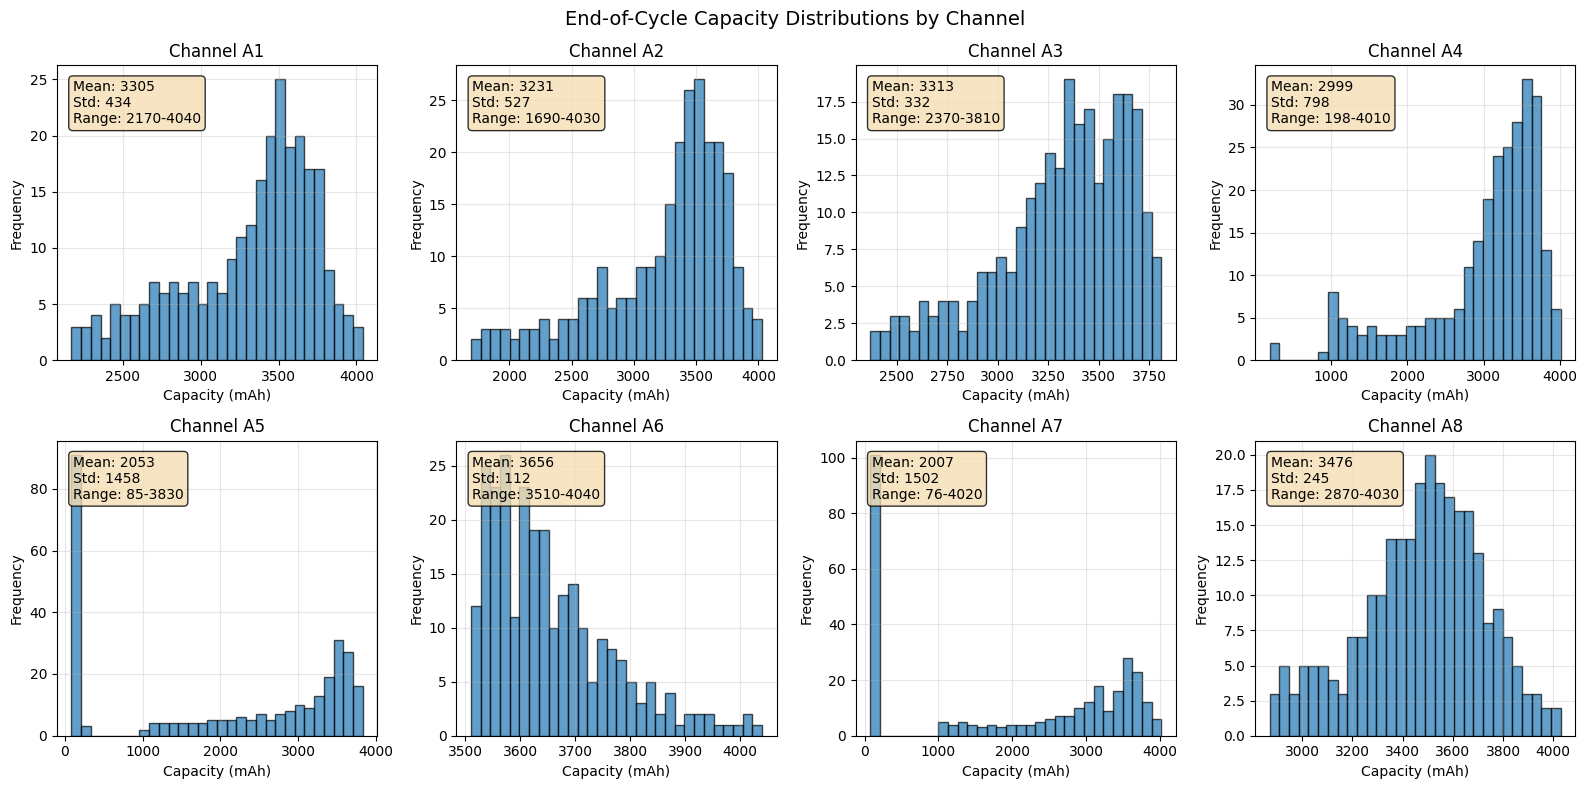

In [11]:
# Visualize end-of-cycle capacity distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('End-of-Cycle Capacity Distributions by Channel', fontsize=14)

for i, (channel, capacities) in enumerate(end_of_cycle_capacities.items()):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    if capacities is not None and len(capacities) > 0:
        ax.hist(capacities, bins=30, alpha=0.7, edgecolor='black')
        ax.set_title(f'Channel {channel}')
        ax.set_xlabel('Capacity (mAh)')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        
        # Add stats text
        stats_text = f'Mean: {capacities.mean():.0f}\nStd: {capacities.std():.0f}\nRange: {capacities.min():.0f}-{capacities.max():.0f}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Channel {channel}')

plt.tight_layout()
plt.show()

In [24]:
# Compare train vs test channels end-of-cycle capacity
train_channels = config.TRAIN_CHANNELS
test_channels = config.TEST_CHANNELS

print("TRAIN CHANNELS (used for model training):")
train_capacities_all = []
for channel in train_channels:
    if channel in end_of_cycle_capacities:
        capacities = end_of_cycle_capacities[channel]
        train_capacities_all.extend(capacities.values)
        print(f"Channel {channel}: {capacities.min():.1f} - {capacities.max():.1f} mAh (mean: {capacities.mean():.1f})")

print(f"\nOverall Train Range: {np.min(train_capacities_all):.1f} - {np.max(train_capacities_all):.1f} mAh")

print("\n\nTEST CHANNELS (used for model testing):")
test_capacities_all = []
for channel in test_channels:
    if channel in end_of_cycle_capacities:
        capacities = end_of_cycle_capacities[channel]
        test_capacities_all.extend(capacities.values)
        print(f"Channel {channel}: {capacities.min():.1f} - {capacities.max():.1f} mAh (mean: {capacities.mean():.1f})")

print(f"\nOverall Test Range: {np.min(test_capacities_all):.1f} - {np.max(test_capacities_all):.1f} mAh")

TRAIN CHANNELS (used for model training):
Channel A1: 3050.0 - 4040.0 mAh (mean: 3525.2)
Channel A2: 2960.0 - 4040.0 mAh (mean: 3494.3)
Channel A3: 3140.0 - 3810.0 mAh (mean: 3474.6)
Channel A4: 2790.0 - 4010.0 mAh (mean: 3404.1)
Channel A7: 193.0 - 4020.0 mAh (mean: 2969.9)
Channel A8: 3340.0 - 4030.0 mAh (mean: 3592.1)

Overall Train Range: 193.0 - 4040.0 mAh


TEST CHANNELS (used for model testing):
Channel A2: 2960.0 - 4040.0 mAh (mean: 3494.3)
Channel A5: 1190.0 - 3840.0 mAh (mean: 2992.3)

Overall Test Range: 1190.0 - 4040.0 mAh
